# Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Load Data

In [2]:
df = pd.read_csv(r"..\data\balanced_product_reviews.csv", encoding='latin-1')

print("balanced_product_reviews dataset shape:", df.shape)


balanced_product_reviews dataset shape: (10000, 3)


# View Data

In [3]:

print("\nbalanced_product_reviews dataset:")
df.head()
df.tail()
df.sample(5)
df.info()
df.describe()




balanced_product_reviews dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Rating        10000 non-null  int64 
 1   Review        10000 non-null  object
 2   ReviewLength  10000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 234.5+ KB


,Rating,ReviewLength
count,10000.000000,10000.000000
mean,3.000000,660.692800
std,1.414284,598.345177
min,1.000000,10.000000
25%,2.000000,257.000000
50%,3.000000,484.000000
75%,4.000000,861.250000
max,5.000000,4777.000000


#  Selecting Columns

In [4]:
df = df[['Rating','Review']]

print("Final dataset columns:", df.columns)

print("Final dataset shape:", df.shape)


Final dataset columns: Index(['Rating', 'Review'], dtype='object')
Final dataset shape: (10000, 2)


# Data Visualization of balanced Data

# Rating Distribution (Bar Chart)

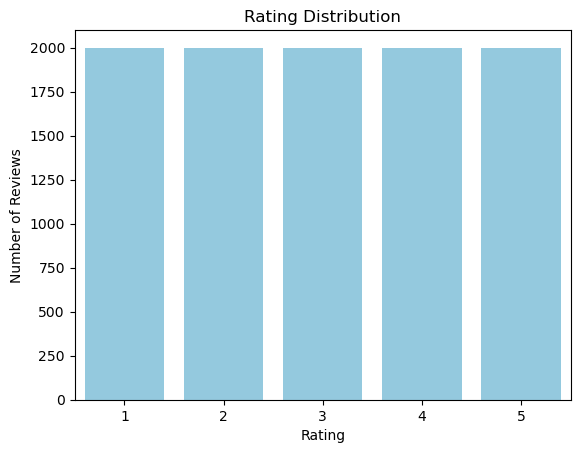

In [5]:
sns.countplot(x='Rating', data=df, color='skyblue')  
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

# Rating Distribution (Pie Chart)

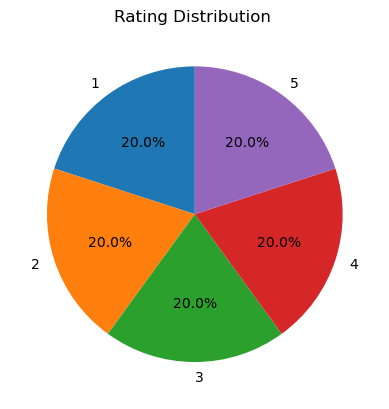

In [6]:

rating_counts = df['Rating'].value_counts().sort_index()

# Labels and values
categories = rating_counts.index
values = rating_counts.values

# Plot pie chart
plt.pie(values, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title("Rating Distribution ")
plt.show()


# Natural Language Processing (NLP)

# Lowercase All Text

In [7]:
df = df[['Rating', 'Review']]
# Convert Review text to lowercase
df['Review'] = df['Review'].str.lower()
# Reset index
df.reset_index(drop=True, inplace=True)

print(df.head())
print("Dataset shape:", df.shape)


   Rating                                             Review
0       1  second to worst dining experience of all time ...
1       1  my wife and i live around the corner hadnt eat...
2       1  awful not sure it classifies as food burrito c...
3       1  absolutely disgusting i had enchiladas and a t...
4       1  they served us stale rice average main dishes ...
Dataset shape: (10000, 2)


# Remove URL

In [8]:
def remove_url(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub('', text)  # Replace URLs with empty string

df['Review'] = df['Review'].apply(remove_url)

df['Review'].head()


0    second to worst dining experience of all time ...
1    my wife and i live around the corner hadnt eat...
2    awful not sure it classifies as food burrito c...
3    absolutely disgusting i had enchiladas and a t...
4    they served us stale rice average main dishes ...
Name: Review, dtype: object

# Remove HTML tags

In [9]:
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'',text)
df['Review'] =df['Review'].apply(remove_html_tags)

df['Review'].head()

0    second to worst dining experience of all time ...
1    my wife and i live around the corner hadnt eat...
2    awful not sure it classifies as food burrito c...
3    absolutely disgusting i had enchiladas and a t...
4    they served us stale rice average main dishes ...
Name: Review, dtype: object

# Remove emojis, punctuation and special characters

In [10]:
import string

punctuation_list = string.punctuation
print(f'The punctuations are {punctuation_list}')



The punctuations are !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [11]:
def clean_text_punct(text):
    # Remove punctuation
    for char in punctuation_list:
        text = text.replace(char, '')
    # Remove extra spaces
    text = ' '.join(text.split())
    return text

df['Review'] = df['Review'].apply(clean_text_punct)
df['Review'].head()

0    second to worst dining experience of all time ...
1    my wife and i live around the corner hadnt eat...
2    awful not sure it classifies as food burrito c...
3    absolutely disgusting i had enchiladas and a t...
4    they served us stale rice average main dishes ...
Name: Review, dtype: object

# Showing stopwords 

In [12]:
import spacy
nlp = spacy.load("en_core_web_sm")

def show_stopwords_in_text(text):
    doc = nlp(text)
    present_stopwords = [token.text for token in doc if token.is_stop]
    return present_stopwords

df['Stopwords_in_Review'] = df['Review'].apply(show_stopwords_in_text)
df[['Review', 'Stopwords_in_Review']].head()

,Review,Stopwords_in_Review
0,second to worst dining experience of all time ...,"[to, of, all, our, was, a, which, is, but, it,..."
1,my wife and i live around the corner hadnt eat...,"[my, and, i, around, the, had, here, in, a, fe..."
2,awful not sure it classifies as food burrito c...,"[not, it, as, of, a, and, no, they, you, anyth..."
3,absolutely disgusting i had enchiladas and a t...,"[i, had, and, a, just, to, give, them, a, this..."
4,they served us stale rice average main dishes ...,"[they, us, not, as, not, enough, in, the]"


# Remove stopwords

In [13]:
def remove_stopwords(text):
    doc = nlp(text)
    filtered_text = " ".join([token.text for token in doc if not token.is_stop])
    return filtered_text

df['Review'] = df['Review'].apply(remove_stopwords)
df['Review'].head()


0    second worst dining experience time waitress l...
1    wife live corner nt eaten months got food mong...
2    awful sure classifies food burrito consists fl...
3    absolutely disgusting enchiladas taco chance w...
4    served stale rice average main dishes flavorfu...
Name: Review, dtype: object

# Apply Lemmatization

In [14]:
def lemmatize_text(text):
    doc = nlp(text)
    lemma_list = [token.lemma_ for token in doc]   # list format
    lemma_joined = " ".join(lemma_list)            # joined format
    return lemma_list, lemma_joined

# Apply and expand into two columns
df[['Review_List', 'REVIEW']] = df['Review'].apply(lambda x: pd.Series(lemmatize_text(x)))

print("List format:\n", df['Review_List'].head())
print("\nJoined format:\n", df['REVIEW'].head())



List format:
 0    [second, bad, dining, experience, time, waitre...
1    [wife, live, corner, not, eat, month, get, foo...
2    [awful, sure, classifie, food, burrito, consis...
3    [absolutely, disgusting, enchiladas, taco, cha...
4    [serve, stale, rice, average, main, dish, flav...
Name: Review_List, dtype: object

Joined format:
 0    second bad dining experience time waitress lit...
1    wife live corner not eat month get food mongol...
2    awful sure classifie food burrito consist flou...
3    absolutely disgusting enchiladas taco chance b...
4    serve stale rice average main dish flavorful m...
Name: REVIEW, dtype: object


# Filter out reviews with: Fewer than minimum words and Excessively long text

In [15]:
# Calculate word count for each review
df['Word_Count'] = df['REVIEW'].apply(lambda x: len(x.split()))

df = df[(df['Word_Count'] >= 3) & (df['Word_Count'] <= 250)]

# Check the filtered dataset
print("Original dataset shape:", df.shape)
print("Filtered dataset shape:", df.shape)
df[['REVIEW', 'Word_Count']].head()


Original dataset shape: (9868, 6)
Filtered dataset shape: (9868, 6)


,REVIEW,Word_Count
0,second bad dining experience time waitress lit...,100
1,wife live corner not eat month get food mongol...,61
2,awful sure classifie food burrito consist flou...,39
3,absolutely disgusting enchiladas taco chance b...,21
4,serve stale rice average main dish flavorful m...,11


# Visualization 

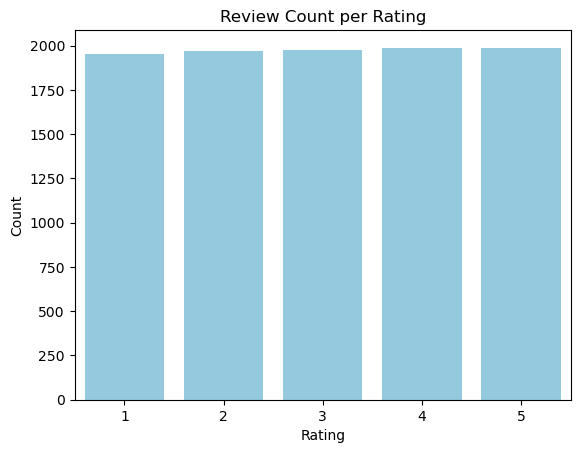

In [16]:
sns.countplot(x='Rating', data=df, color='skyblue')
plt.title('Review Count per Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Create Balanced Dataset

In [17]:
min_count = 2000  

# List to hold balanced DataFrames
balanced_df_list = []

# Loop through each unique rating
for rating in df['Rating'].unique():
    df_rating = df[df['Rating'] == rating][['REVIEW', 'Rating']]
    
    if len(df_rating) < min_count:
        # Oversample minority class (with replacement)
        df_rating_balanced = df_rating.sample(min_count, replace=True, random_state=42)
    else:
        # Undersample majority class (without replacement)
        df_rating_balanced = df_rating.sample(min_count, replace=False, random_state=42)
    
    balanced_df_list.append(df_rating_balanced)

# Concatenate all ratings and shuffle
df_balanced = pd.concat(balanced_df_list).sample(frac=1, random_state=42).reset_index(drop=True)

# Check rating distribution
print("Balanced dataset distribution:\n", df_balanced['Rating'].value_counts())

# Shape of the balanced dataset
print("Balanced dataset shape:", df_balanced.shape)


df_balanced.head()

Balanced dataset distribution:
 Rating
4    2000
3    2000
1    2000
2    2000
5    2000
Name: count, dtype: int64
Balanced dataset shape: (10000, 2)


,REVIEW,Rating
0,zipp rock place tv screen viewable angle atmos...,4
1,probably overrate place phoenix area pizza tas...,3
2,bad restaurant term hygiene friend food poison...,1
3,sis recommend place weekly dinner share large ...,3
4,ve probably pass place thousand time stop toda...,3


# Data Visualization

# Bar plot: Review count per rating

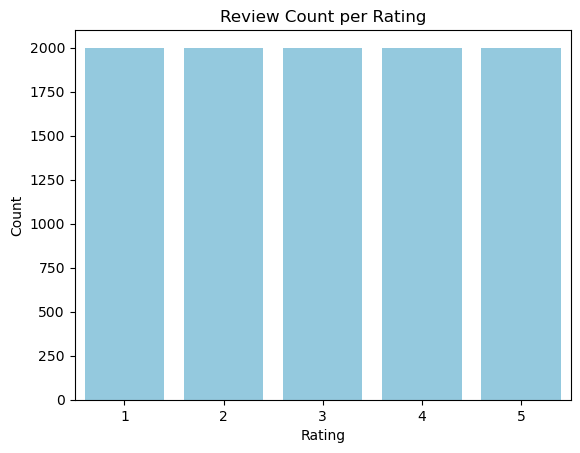

In [18]:
sns.countplot(x='Rating', data=df_balanced, color='skyblue')
plt.title('Review Count per Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Word count 

In [19]:
df_balanced.loc[:, 'Word_Count'] = df_balanced['REVIEW'].str.split().str.len()

df_balanced[['REVIEW', 'Word_Count']].head()



,REVIEW,Word_Count
0,zipp rock place tv screen viewable angle atmos...,33
1,probably overrate place phoenix area pizza tas...,38
2,bad restaurant term hygiene friend food poison...,82
3,sis recommend place weekly dinner share large ...,43
4,ve probably pass place thousand time stop toda...,82


# Histogram for Word Count

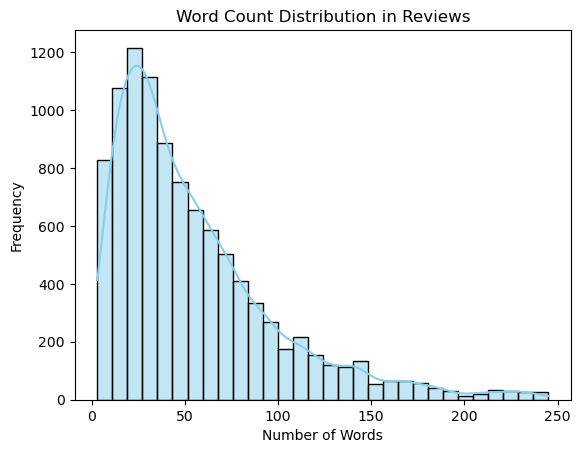

In [20]:

sns.histplot(df_balanced['Word_Count'], bins=30, kde=True, color='skyblue')
plt.title('Word Count Distribution in Reviews')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Box Plot: Word count by Rating

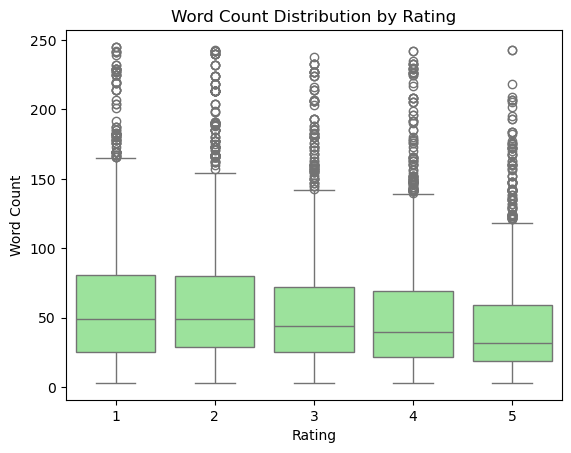

In [21]:


sns.boxplot(x='Rating', y='Word_Count', data=df_balanced, color='lightgreen')
plt.title('Word Count Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.show()

# full sample reviews per rating

In [22]:
for rating, group in df_balanced.groupby('Rating'):
    print(f"\n--- Rating: {rating} ---\n")
    sample_reviews = df_balanced[df_balanced['Rating'] == rating]['REVIEW'].sample(
        n=min(5, len(df_balanced[df_balanced['Rating'] == rating])),
        random_state=42)
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review}\n")



--- Rating: 1 ---

1. hopeful october scottsdale yummy tacoswow rip 10 shade buying drink place not salsa taco sauce measly price taco like vulture not care customer 2 ticket grab beg napkin hunt place sit feel watch vulture wait ready leave 45 minute pepsi get warm get cup ice bar pour take drink leave hike car security stop not let booze angry little local dump trash say sweet daughter law mad outta bring 2 year old thinking fun way spend saturday morning encourage local business nope good

2. donut worst ve buy 2 dozen donut 1099 sale bad donut life donut dry stale go couple mile buy krispy kreme krispy kreme donut fresh one worst sit shelf week supermarket

3. refuse water young teen refer pf chang olive ivy handle poorly unprofessionally pathetically pf chang not hesitate water s eat instead

4. honestly not go do gringo good friend weekend phoenix excite city offer enter do gringo sit table 21 minute waitress come table bring 2 beer come 40 minute decide check new bar obviously 

# Shuffle the dataset

In [23]:
# Shuffle the balanced dataset
df_shuffled = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

df_shuffled[['REVIEW', 'Rating']].head()


,REVIEW,Rating
0,not want write review place near dear heart ba...,4
1,history architecture site building able walk g...,5
2,pizzait like pizza pillow tasty savory doughy ...,3
3,decent place legit chinese food usual fast ser...,3
4,look car wash vacuum area selectione francis s...,1


# Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split

X = df_balanced['REVIEW']   # Text data
y = df_balanced['Rating']          # Target labels

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))


Training set size: 8000
Test set size: 2000


# Preprocessing

In [25]:

nlp = spacy.load('en_core_web_sm')

def spacy_preprocess(text):
    doc = nlp(text.lower())  # Lowercase and tokenize
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return ' '.join(tokens)


In [26]:
# Preprocess training set
X_train_processed = X_train.apply(spacy_preprocess)

# Preprocess test set
X_test_processed = X_test.apply(spacy_preprocess)

print("X_train_preprocessed:")
print(X_train_processed.head())
print("X_test_preprocessed:")
print(X_test_processed.head())



X_train_preprocessed:
2203    coffeemeh great horrible sconedry serviceridic...
9737    impress stop x wait long reservation time frie...
8977    visit jan order thai basil signature dish cala...
8396    food middle road staff rude like start owner t...
4713    accuse training wife compensation tell leave g...
Name: REVIEW, dtype: object
X_test_preprocessed:
4220    ok m del taco chance good chicken idem um burr...
1413    couple time block live typical neighborhood ba...
2355    chip salsa star salsa food good way eat fajita...
1988                                 good bbq thank later
6214    order return chicken tender undr cook rubbery ...
Name: REVIEW, dtype: object


# Vectorize text using:TF-IDF

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2), stop_words='english')

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
print("TF-IDF training set shape:", X_train_tfidf.shape)

X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)
print("TF-IDF test set shape:", X_test_tfidf.shape)



TF-IDF training set shape: (8000, 5000)
TF-IDF test set shape: (2000, 5000)


In [28]:
print("Number of features in TF-IDF:", len(tfidf_vectorizer.get_feature_names_out()))
print("Sample features:", tfidf_vectorizer.get_feature_names_out()[:30])


Number of features in TF-IDF: 5000
Sample features: ['ability' 'able' 'absolute' 'absolutely' 'absolutely amazing'
 'absolutely flavor' 'absolutely love' 'ac' 'academic' 'accent' 'accept'
 'acceptable' 'access' 'accessible' 'accessory' 'accident' 'accommodate'
 'accompany' 'accord' 'account' 'acknowledge' 'acoustic' 'acrid' 'acrylic'
 'act' 'act like' 'action' 'active' 'activity' 'actual']


# Original Reviews and Ratings for Training and Test Sets

In [29]:
# Training set
print("REVIEW and Rating from training set:")
train_df_sample = pd.DataFrame({'REVIEW': X_train, 'Rating': y_train}).reset_index(drop=True)
print(train_df_sample.head(), "\n")  # Added \n for separation

# Test set
print("REVIEW and Rating from test set:")
test_df_sample = pd.DataFrame({'REVIEW': X_test, 'Rating': y_test}).reset_index(drop=True)
print(test_df_sample.head())


REVIEW and Rating from training set:
                                              REVIEW  Rating
0  coffeemeh great horrible sconedry serviceridic...       1
1  impressed stop 2 x wait long reservation 5 tim...       4
2  visit jan 19 order thai basil signature dish c...       3
3  food middle road staff rude like start owner t...       1
4  accuse training wife compensation tell leave g...       1 

REVIEW and Rating from test set:
                                              REVIEW  Rating
0  ok m give del taco chance good chicken idem um...       1
1  couple time block live typical neighborhood ba...       2
2  chip salsa 5 star salsa food good way eat faji...       3
3                               good bbq thank later       5
4  order return chicken tender undr cook rubbery ...       1


# Top TF-IDF Features per Review with Corresponding Ratings

In [30]:

def top_tfidf_features_per_review(tfidf_matrix, feature_names, ratings, top_n=5):
  
    # Ensure dense format
    if not isinstance(tfidf_matrix, np.ndarray):
        tfidf_dense = tfidf_matrix.toarray()
    else:
        tfidf_dense = tfidf_matrix

    top_features_list = []

    for i in range(tfidf_dense.shape[0]):
        row = tfidf_dense[i]
        top_indices = row.argsort()[-top_n:][::-1]  # Indices of top N features
        top_features = [feature_names[idx] for idx in top_indices]
        top_scores = [row[idx] for idx in top_indices]
        
        top_features_list.append({
            'Rating': ratings.iloc[i] if hasattr(ratings, 'iloc') else ratings[i],
            'Top_Features': top_features,
            'TF-IDF_Scores': top_scores
        })

    return pd.DataFrame(top_features_list)

feature_names = tfidf_vectorizer.get_feature_names_out()
top_features_df = top_tfidf_features_per_review(X_train_tfidf, feature_names, y_train, top_n=5)

top_features_df.head()


,Rating,Top_Features,TF-IDF_Scores
0,1,"[pay customer, customer, pay, owner come, dist...","[0.47842997695469736, 0.2303652870028023, 0.22..."
1,4,"[excellent, time friend, advertise, bad meal, ...","[0.2546621436179573, 0.2164445646995514, 0.205..."
2,3,"[dish, order, clay pot, clay, dish good]","[0.30786550848460115, 0.20181594742399292, 0.1..."
3,1,"[choice area, choice, wrong, fix issue, wrong ...","[0.4346146442104889, 0.3598787323201044, 0.231..."
4,1,"[compensation, trainer, wife, gym, training]","[0.36744444301322343, 0.3557685071338308, 0.34..."


In [38]:
top_features_df.tail()

,Rating,Top_Features,TF-IDF_Scores
7995,1,"[salsa, come, cilantro, taco, meat]","[0.29791307826512436, 0.2489043253494343, 0.22..."
7996,2,"[glass, lack, flame, ve want, miso soup]","[0.228770169236689, 0.2264513176429563, 0.1820..."
7997,2,"[college, bar, usually, summer heat, college kid]","[0.3648577748996445, 0.22982921323368613, 0.19..."
7998,4,"[decide, sunny, coffee shop, east coast, decid...","[0.3282104361251101, 0.29853927787507195, 0.29..."
7999,5,"[willow, shoulder, facial, spa, massage]","[0.3619608761483841, 0.2527257078372993, 0.250..."


# Convert TF-IDF Matrices to DataFrames

In [36]:

feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert TF-IDF matrix to DataFrame
tfidf_df_train = pd.DataFrame(X_train_tfidf.toarray(), columns=feature_names)

# Add Rating column
tfidf_df_train['Rating'] = y_train.reset_index(drop=True)


tfidf_df_train.head()


,ability,able,absolute,absolutely,absolutely amazing,absolutely flavor,absolutely love,ac,academic,accent,...,yuck,yum,yummy,yung,zero,zero star,zipp,zu,zucchini,Rating
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [37]:
tfidf_df_train.tail()

,ability,able,absolute,absolutely,absolutely amazing,absolutely flavor,absolutely love,ac,academic,accent,...,yuck,yum,yummy,yung,zero,zero star,zipp,zu,zucchini,Rating
7995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.052657,0.0,0.0,0.0,0.0,0.0,0.0,1
7996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,2
7997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,2
7998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,4
7999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,5
